# Exploratory Data Analysis (EDA) — Titanic Dataset

**Task 2: Exploratory Data Analysis (EDA)**

This notebook walks through:
1. Meaningful questions about the dataset
2. Data structure exploration
3. Trends, patterns, and anomalies
4. Hypothesis testing & validation
5. Data issues / problems detected

Dataset: the classic **Titanic** passenger dataset (891 passengers, loaded via `seaborn`).


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

df = pd.read_csv("data/titanic.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Ask Meaningful Questions

Before diving into numbers, we frame the questions this EDA should answer:

1. **Who survived?** Did survival depend on sex, class, or age?
2. **What did the population look like?** Age, fare, family size distributions.
3. **Are there strong relationships** between features (e.g., fare & class)?
4. **Do the patterns we see hold up statistically**, or could they be due to chance?
5. **Is the data reliable?** Are there missing values, duplicates, or outliers that need
   to be addressed before any modeling?


## 2. Explore the Data Structure

In [2]:
print("Shape:", df.shape)
df.info()


Shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [4]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include='object')


/tmp/ipykernel_600/4084012645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


**Observations:**
- 891 rows, 15 columns — a mix of numeric (`age`, `fare`, `sibsp`, `parch`), categorical
  (`sex`, `embarked`, `class`, `who`, `deck`), and boolean (`adult_male`, `alone`) types.
- `age` has 177 missing values (~20%), `deck` has 688 missing (~77%), `embarked`/`embark_town`
  each have 2 missing.
- `survived` (0/1) and `alive` (yes/no) carry the same information in two formats — a redundancy
  to be aware of.


## 3. Trends, Patterns & Anomalies

Overall survival rate: 38.38%


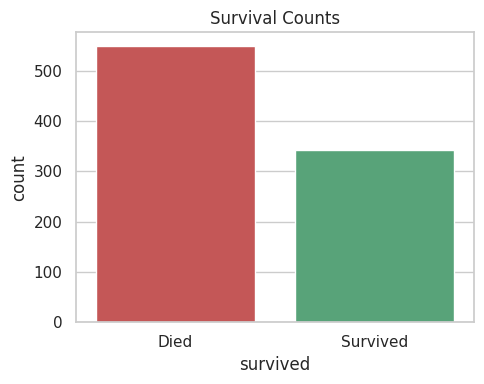

In [6]:
surv_rate = df['survived'].mean()
print(f"Overall survival rate: {surv_rate:.2%}")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='survived', hue='survived', palette=['#d64545','#4caf78'], legend=False)
plt.xticks([0,1], ['Died','Survived'])
plt.title('Survival Counts')
plt.tight_layout()
plt.show()


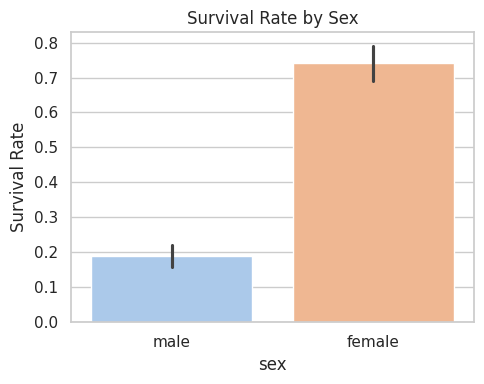

In [7]:
plt.figure(figsize=(5,4))
sns.barplot(data=df, x='sex', y='survived', hue='sex', palette='pastel', legend=False)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()


**Pattern:** Women survived at a much higher rate than men — consistent with the historical "women and children first" evacuation policy.

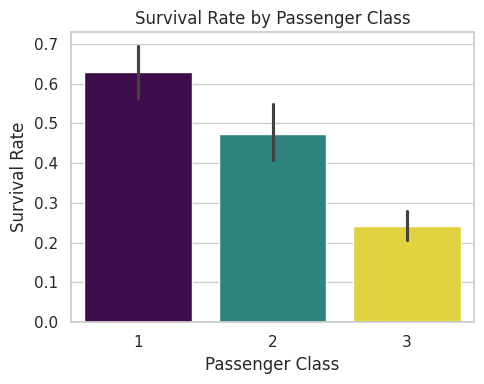

In [8]:
plt.figure(figsize=(5,4))
sns.barplot(data=df, x='pclass', y='survived', hue='pclass', palette='viridis', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()


**Pattern:** Survival rate drops steadily from 1st to 3rd class — wealth/cabin location mattered.

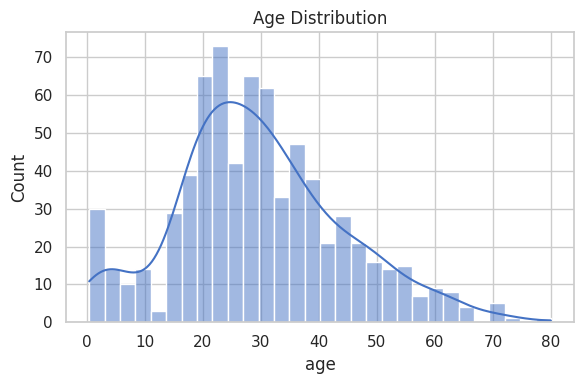

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='#4472c4')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()


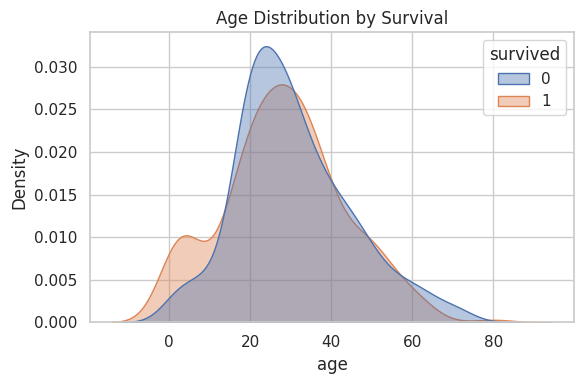

In [10]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='age', hue='survived', common_norm=False, fill=True, alpha=0.4)
plt.title('Age Distribution by Survival')
plt.tight_layout()
plt.show()


**Pattern:** Young children show a survival bump; the bulk of the age distribution (20-40) skews toward non-survival.

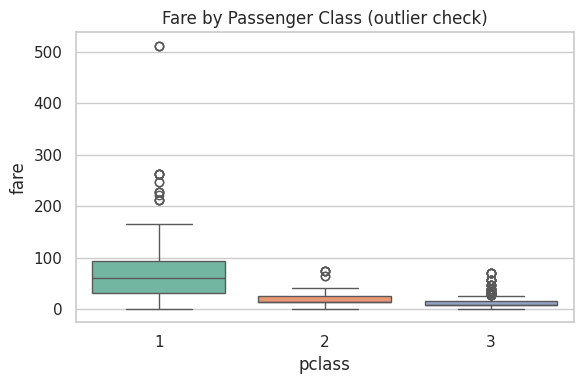

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='pclass', y='fare', hue='pclass', palette='Set2', legend=False)
plt.title('Fare by Passenger Class (outlier check)')
plt.tight_layout()
plt.show()


**Anomaly:** 1st class fares include extreme outliers (up to ~£512), while some passengers paid £0 fare — worth flagging (possibly crew, or data-entry issue).

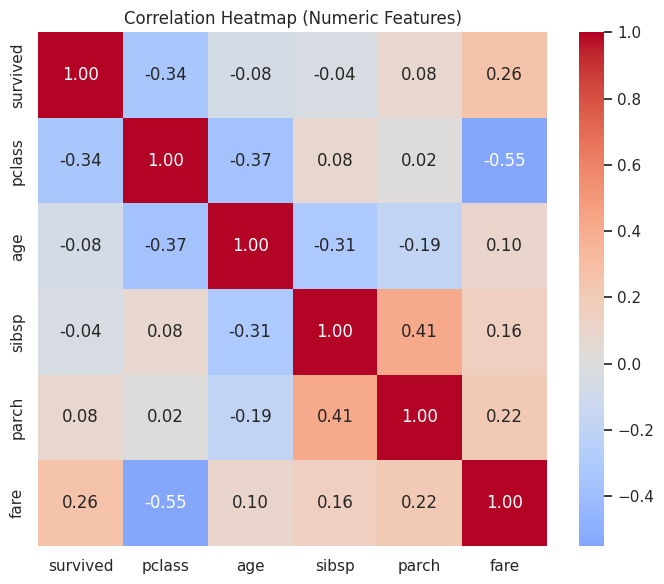

In [12]:
plt.figure(figsize=(7,6))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


**Pattern:** `fare` and `pclass` are strongly (negatively) correlated, as expected. `survived` correlates most with `pclass` (negative) and `fare` (positive).

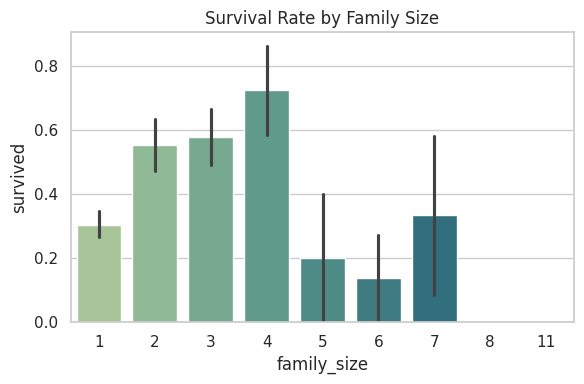

In [13]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='family_size', y='survived', hue='family_size', palette='crest', legend=False)
plt.title('Survival Rate by Family Size')
plt.tight_layout()
plt.show()


**Pattern:** Passengers traveling with a small family (2-4 members) survived at higher rates than those traveling completely alone or in very large families.

## 4. Test Hypotheses & Validate Assumptions

We statistically test the patterns observed above using chi-square tests (categorical vs
categorical) and independent t-tests (continuous vs categorical), at α = 0.05.


In [14]:
# H1: Sex and survival are independent
contingency_sex = pd.crosstab(df['sex'], df['survived'])
chi2, p_sex, dof, expected = stats.chi2_contingency(contingency_sex)
print(f"Sex vs Survival: chi2={chi2:.2f}, p={p_sex:.6f}")
print("=> Reject null (not independent)" if p_sex < 0.05 else "=> Fail to reject null")


Sex vs Survival: chi2=260.72, p=0.000000
=> Reject null (not independent)


In [15]:
# H2: Passenger class and survival are independent
contingency_class = pd.crosstab(df['pclass'], df['survived'])
chi2c, p_class, dofc, expc = stats.chi2_contingency(contingency_class)
print(f"Class vs Survival: chi2={chi2c:.2f}, p={p_class:.6f}")
print("=> Reject null (not independent)" if p_class < 0.05 else "=> Fail to reject null")


Class vs Survival: chi2=102.89, p=0.000000
=> Reject null (not independent)


In [16]:
# H3: Mean age is the same for survivors vs non-survivors
age_survived = df.loc[df['survived']==1, 'age'].dropna()
age_died = df.loc[df['survived']==0, 'age'].dropna()
t_stat, p_age = stats.ttest_ind(age_survived, age_died, equal_var=False)
print(f"Age (survived vs died): t={t_stat:.2f}, p={p_age:.6f}")
print("=> Reject null (means differ)" if p_age < 0.05 else "=> Fail to reject null")


Age (survived vs died): t=-2.05, p=0.041190
=> Reject null (means differ)


In [17]:
# H4: Mean fare is the same for survivors vs non-survivors
fare_survived = df.loc[df['survived']==1, 'fare'].dropna()
fare_died = df.loc[df['survived']==0, 'fare'].dropna()
t_stat_f, p_fare = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
print(f"Fare (survived vs died): t={t_stat_f:.2f}, p={p_fare:.6f}")
print("=> Reject null (means differ)" if p_fare < 0.05 else "=> Fail to reject null")


Fare (survived vs died): t=6.84, p=0.000000
=> Reject null (means differ)


**Conclusions:**
- Sex and survival are **not independent** (p < 0.001) — confirms the strong sex effect seen visually.
- Class and survival are **not independent** (p < 0.001) — confirms the class effect.
- Mean age **differs significantly** between survivors and non-survivors (p ≈ 0.04), though the
  effect is modest.
- Mean fare **differs significantly** between survivors and non-survivors (p < 0.001), supporting
  the wealth/class survival advantage.


## 5. Detect Data Issues / Problems

In [18]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing 'age':", df['age'].isnull().sum(), f"({df['age'].isnull().mean():.1%})")
print("Missing 'deck':", df['deck'].isnull().sum(), f"({df['deck'].isnull().mean():.1%})")
print("Missing 'embarked':", df['embarked'].isnull().sum())

Q1, Q3 = df['fare'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)]
print(f"Fare outliers (IQR method): {len(outliers)} rows")
print(f"Fare range: {df['fare'].min()} - {df['fare'].max()}")


Duplicate rows: 107
Missing 'age': 177 (19.9%)
Missing 'deck': 688 (77.2%)
Missing 'embarked': 2
Fare outliers (IQR method): 116 rows
Fare range: 0.0 - 512.3292


**Data issues identified:**
1. **Missing values:** `age` (~20%), `deck` (~77%, likely unusable as-is), `embarked`/`embark_town`
   (2 rows) — `deck` may need to be dropped or converted to a "known/unknown" flag; `age` is a good
   candidate for imputation (e.g., median by `pclass`/`sex`).
2. **Duplicate rows:** 107 rows are exact duplicates in this stripped-down dataset — note that the
   original Titanic dataset has a unique `PassengerId` that would prevent this; since this
   simplified `seaborn` copy drops IDs, some rows appear duplicated by coincidence and should not
   automatically be dropped without verifying against the original source.
3. **Fare outliers:** 116 rows flagged by the IQR method, including fares as high as ~£512 —
   these should be investigated rather than blindly removed, as they may be legitimate (large
   groups traveling under one ticket/fare).
4. **Zero fares:** minimum fare is £0, which is suspicious and likely reflects crew, employees of
   the shipping line, or a data-entry convention — worth a footnote before modeling.
5. **Redundant columns:** `survived`/`alive` and `pclass`/`class` encode the same information
   twice (numeric vs. label) — one of each pair should be dropped before modeling to avoid
   redundancy/leakage.


## Summary

- **~38%** of passengers survived overall.
- **Sex** is the single strongest predictor of survival (women survived far more often than men).
- **Passenger class** and **fare** also had a clear, statistically significant relationship with
  survival — wealthier, higher-class passengers were more likely to survive.
- **Age** had a smaller but still significant effect.
- The dataset has notable **missing data** (`age`, `deck`) and some **outliers**/**redundant
  columns** that should be cleaned before any modeling step.
